In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import pickle
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestRegressor
import joblib
from datetime import datetime


# Download and initialize VADER lexicon
nltk.download('vader_lexicon')
analyzer = SentimentIntensityAnalyzer()

# Load data
df = pd.read_csv("data\customer_data.csv")
df['Last_Activity'] = pd.to_datetime(df['Last_Activity'])

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\sRjN\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [123]:

# polarity_scores returns a dict: {'neg', 'neu', 'pos', 'compound'}
def get_vader_sentiment(text):
    if pd.isna(text):
        return 0.0
    return analyzer.polarity_scores(text)['compound']

# Apply sentiment analysis
df['Sentiment_Score'] = df['Review_Text'].apply(get_vader_sentiment)

In [124]:
#Recency Calculation: Days since last activity
snapshot_date = df['Last_Activity'].max() + pd.Timedelta(days=1)
df['Recency'] = (snapshot_date - df['Last_Activity']).dt.days

#Features for Clustering
features = ['Booking_Frequency', 'Avg_Spending', 'Sentiment_Score', 'Recency']
X = df[features]

#Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

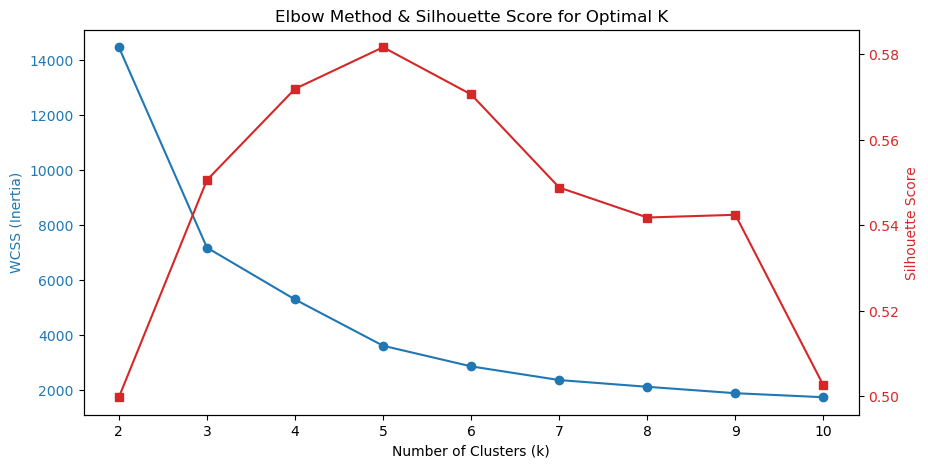

In [ ]:
wcss = []
silhouette_avg = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = km.fit_predict(X_scaled)
    
    wcss.append(km.inertia_)
    silhouette_avg.append(silhouette_score(X_scaled, cluster_labels))

# Plotting the results
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Elbow
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color='tab:blue')
ax1.plot(k_range, wcss, marker='o', color='tab:blue', label='WCSS')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot Silhouette
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(k_range, silhouette_avg, marker='s', color='tab:red', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Elbow Method & Silhouette Score for Optimal K')
plt.show()

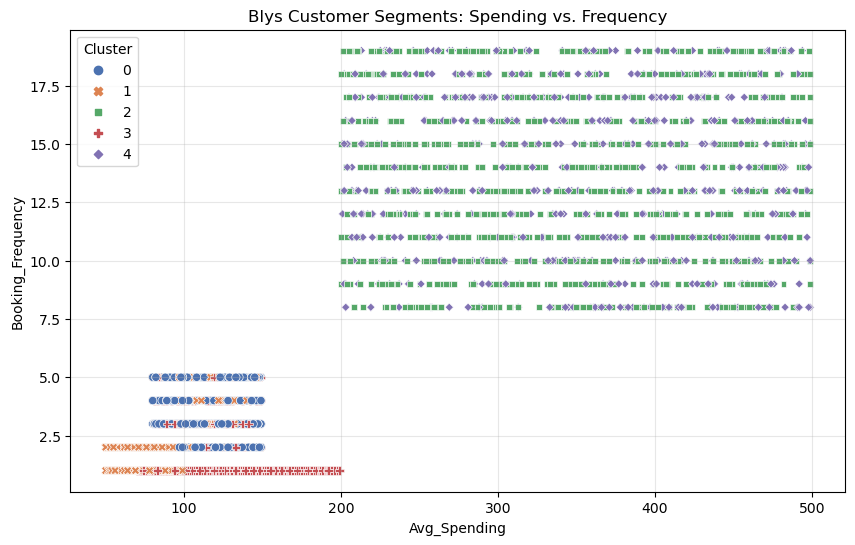

In [126]:
# Apply K-Means
kmeans = KMeans(n_clusters=5, random_state=43, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualize the segments
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Avg_Spending', 
    y='Booking_Frequency', 
    hue='Cluster', 
    palette='deep',
    style='Cluster'
)
plt.title('Blys Customer Segments: Spending vs. Frequency')
plt.grid(True, alpha=0.3)
plt.show()

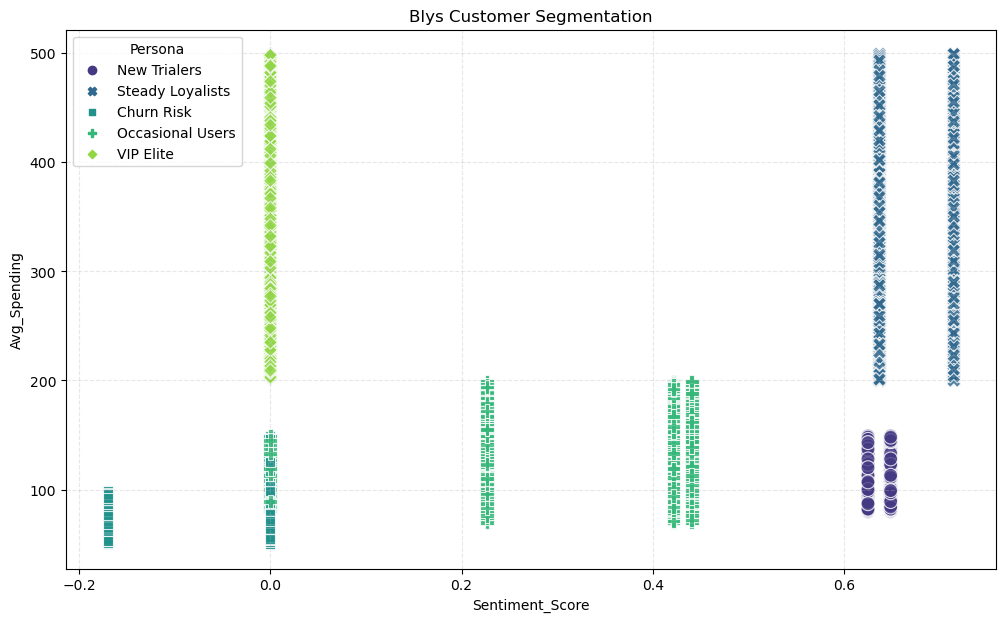

Cluster Counts:
Persona
Churn Risk          2160
Occasional Users    1988
Steady Loyalists    1205
New Trialers        1082
VIP Elite            565
Name: count, dtype: int64


In [127]:
cluster_summary = df.groupby('Cluster')[features].mean()
ranked_clusters = cluster_summary.sort_values(by='Avg_Spending', ascending=False).index.tolist()
persona_map = {
    ranked_clusters[0]: ("VIP Elite", "Personal Account Manager & Early Access."),
    ranked_clusters[1]: ("Steady Loyalists", "Loyalty Points & Referral Bonuses."),
    ranked_clusters[2]: ("Occasional Users", "Service Bundles & Seasonal Promos."),
    ranked_clusters[3]: ("New Trialers", "Welcome Series & Second-Booking Discount."),
    ranked_clusters[4]: ("Churn Risk", "Re-engagement 'Win-back' 20% Discount.")
}

df['Persona'] = df['Cluster'].map(lambda x: persona_map[x][0])
df['Action_Plan'] = df['Cluster'].map(lambda x: persona_map[x][1])

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df, 
    x='Sentiment_Score', 
    y='Avg_Spending', 
    hue='Persona',
    style='Persona',
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('Blys Customer Segmentation')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

print("Cluster Counts:")
print(df['Persona'].value_counts())

In [128]:
# Calculate General Business Metrics
total_customers = len(df)
avg_spend = df['Avg_Spending'].mean()
avg_freq = df['Booking_Frequency'].mean()

# Prepare the Markdown Content
markdown_content = f"""# Blys AI Engineer Assessment: Customer Behavior Analysis

## Executive Summary
This report details the segmentation of **{total_customers}** customers using K-Means clustering ($K=5$) and VADER sentiment analysis. The objective is to identify high-value behaviors and churn risks to drive automated retention strategies.

---

##  High-Level Metrics
* **Total Customer Base:** {total_customers}
* **Average Spending per Customer:** ${avg_spend:.2f}
* **Average Booking Frequency:** {avg_freq:.1f} sessions

---

##  Customer Segmentation (Personas)
We identified 5 distinct segments based on spending habits, booking frequency, recency, and sentiment.

| Persona | Avg. Spending | Avg. Frequency | Sentiment | Primary Strategy |
| :--- | :--- | :--- | :--- | :--- |
"""

# Add Cluster Details Dynamically
for persona in df['Persona'].unique():
    subset = df[df['Persona'] == persona]
    p_spend = subset['Avg_Spending'].mean()
    p_freq = subset['Booking_Frequency'].mean()
    p_sent = subset['Sentiment_Score'].mean()
    p_strat = subset['Action_Plan'].iloc[0]
    
    markdown_content += f"| **{persona}** | ${p_spend:.2f} | {p_freq:.1f} | {p_sent:.2f} | {p_strat} |\n"

# Add Insights & Recommendations
markdown_content += """
---

## 💡 Key Insights & Recommendations

### 1. High-Value Retention (VIP Elite)
* **Insight:** This group contributes the highest revenue but has the highest expectations.
* **Action:** Implement a "Pro-Priority" matching system to ensure they always get the top-rated service providers.

### 2. Churn Mitigation (Churn Risk)
* **Insight:** Identified by high recency (days since last booking) and neutral-to-low sentiment.
* **Action:** Automate a "We Miss You" email sequence triggered when a user exceeds the 45-day inactivity threshold.

### 3. Growth Opportunity (New Trialers)
* **Insight:** Large volume of users with positive sentiment but only 1-2 bookings.
* **Action:** Introduce a "Welcome Bundle" discount for their 3rd booking to convert them into Steady Loyalists.

---
Report generated on:
"""
markdown_content+=str(datetime.now().strftime('%Y-%m-%d'))

# Write to File
with open("customer_analysis.md", "w") as f:
    f.write(markdown_content)

print("Successfully generated customer_analysis.md")

Successfully generated customer_analysis.md


In [129]:
# Generate Service Embeddings
interaction_matrix = df.pivot_table(
    index='Customer_ID', 
    columns='Preferred_Service', 
    values='Booking_Frequency', 
    fill_value=0
)

# Apply SVD to get latent features for services
svd = TruncatedSVD(n_components=3, random_state=43)
svd.fit(interaction_matrix)
service_embedding_map = {
    service: svd.components_.T[i] 
    for i, service in enumerate(interaction_matrix.columns)
}

# Convert the target 'Preferred_Service' into its numerical embedding vector
X = df[['Booking_Frequency', 'Avg_Spending', 'Sentiment_Score', 'Recency']]
y = np.array([service_embedding_map[s] for s in df['Preferred_Service']])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

# Train the model
model = RandomForestRegressor(n_estimators=100, random_state=43)
model.fit(X_train, y_train)

# Evaluate the Model
y_pred_vectors = model.predict(X_test)

def find_closest_service(pred_vector):
    # Find the service with the smallest distance to the predicted vector
    distances = {s: np.linalg.norm(pred_vector - emb) for s, emb in service_embedding_map.items()}
    return min(distances, key=distances.get)

y_pred_labels = [find_closest_service(v) for v in y_pred_vectors]
y_true_labels = [find_closest_service(v) for v in y_test]

# Metrics
mse = mean_squared_error(y_test, y_pred_vectors)
precision = precision_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)
recall = recall_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)

print(f"--- Embedding-Based Recommender Results ---")
print(f"Precision @ 1: {precision:.2f}")
print(f"Recall @ 1:    {recall:.2f}")
print(f"MSE (Vector):  {mse:.2f}")

#Save the model
model_payload = {
    'regressor': model,
    'embedding_map': service_embedding_map,
    'features': ['Booking_Frequency', 'Avg_Spending', 'Sentiment_Score', 'Recency']
}
joblib.dump(model_payload, 'recommendation_model.pkl')

--- Embedding-Based Recommender Results ---
Precision @ 1: 0.34
Recall @ 1:    0.32
MSE (Vector):  0.17


['recommendation_model.pkl']

In [ ]:
# Save Chatbot Config
chatbot_config = {
    "type": "openai_function_calling_chatbot",
    "model": "gpt-5.1",
    "temperature": 0,
    "system_prompt": """
You are a helpful assistant for a booking platform like Blys.

You help users with:
- booking services
- cancelling bookings
- rescheduling bookings
- pricing inquiries

Guidelines:
- Be polite and conversational
- Ask for missing information (like date/time)
- If user wants to perform an action, call the appropriate function
- Always guide the user step-by-step
"""
}

# Save config as chatbot_model.pkl
with open("chatbot_model.pkl", "wb") as f:
    pickle.dump(chatbot_config, f)

print("chatbot_model.pkl saved successfully!")

chatbot_model.pkl saved successfully!
